# **Relaciones Stocks**

In [60]:
###########################################################
# Librerias
###########################################################
import pandas as pd
import dcor
import numpy as np
import yfinance as yf
from dtaidistance import dtw
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from datetime import datetime, timedelta
import networkx as nx
from scipy import stats
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

In [12]:
# ============================================
# 1. DESCARGA Y PREPARACIÓN DE DATOS
# ============================================

# Los 7 magníficos
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'TSLA']
nombres = {
    'AAPL': 'Apple',
    'MSFT': 'Microsoft', 
    'GOOGL': 'Alphabet (Google)',
    'AMZN': 'Amazon',
    'META': 'Meta',
    'NVDA': 'NVIDIA',
    'TSLA': 'Tesla'
}

# Descarga 2 años de datos
end_date = datetime.now()
start_date = end_date - timedelta(days=730)

print("Descargando datos de los 7 Magníficos...")
data = yf.download(tickers, start=start_date, end=end_date, progress=False)

# Extraemos Close y Volume
close_data = data['Close'].dropna()
volume_data = data['Volume'].dropna()

# También descargo SPY y QQQ para comparación
benchmarks = yf.download(['SPY', 'QQQ'], start=start_date, end=end_date, progress=False)['Close']

print(f"Datos descargados: {close_data.shape[0]} días de trading")
print(f"Tickers: {close_data.columns.tolist()}")

Descargando datos de los 7 Magníficos...
Datos descargados: 501 días de trading
Tickers: ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']


##############################################################################################
## **METODO 1: CORRELACIÓN DE PEARSON**
##############################################################################################

* Qué detecta: Relación lineal contemporánea
* Limitación: No detecta relaciones no lineales ni rezagadas

In [26]:
returns=close_data.pct_change().dropna()
returns_log=np.log(close_data / close_data.shift(1)).dropna()

In [29]:
def pearson_analysis(returns):
    """Correlación Pearson + p-values limpios"""
    corr_matrix = returns.corr()

    # matriz vacía para p-values
    p_values = pd.DataFrame(
        np.zeros_like(corr_matrix),
        index=corr_matrix.index,
        columns=corr_matrix.columns
    )

    for i in corr_matrix.index:
        for j in corr_matrix.columns:
            if i!= j:
                _, p = stats.pearsonr(returns[i].dropna(), returns[j].dropna())
                p_values.loc[i, j] = p
            else:
                p_values.loc[i, j] = 0.0 # diagonal, no se testea

    return corr_matrix, p_values

# lo usas igual que antes
pearson_corr, pearson_pvals = pearson_analysis(returns_log)

# comprobación rápida
print(pearson_corr.round(2))
print("\nSignificativos (p<0.05):")
print((pearson_pvals < 0.05) & (pearson_pvals > 0))

Ticker  AAPL  AMZN  GOOGL  META  MSFT  NVDA  TSLA
Ticker                                           
AAPL    1.00  0.48   0.43  0.42  0.38  0.37  0.44
AMZN    0.48  1.00   0.55  0.60  0.52  0.47  0.47
GOOGL   0.43  0.55   1.00  0.43  0.36  0.41  0.47
META    0.42  0.60   0.43  1.00  0.49  0.47  0.42
MSFT    0.38  0.52   0.36  0.49  1.00  0.50  0.38
NVDA    0.37  0.47   0.41  0.47  0.50  1.00  0.47
TSLA    0.44  0.47   0.47  0.42  0.38  0.47  1.00

Significativos (p<0.05):
Ticker   AAPL   AMZN  GOOGL   META   MSFT   NVDA   TSLA
Ticker                                                 
AAPL    False   True   True   True   True   True   True
AMZN     True  False   True   True   True   True   True
GOOGL    True   True  False   True   True   True   True
META     True   True   True  False   True   True   True
MSFT     True   True   True   True  False   True   True
NVDA     True   True   True   True   True  False   True
TSLA     True   True   True   True   True   True  False


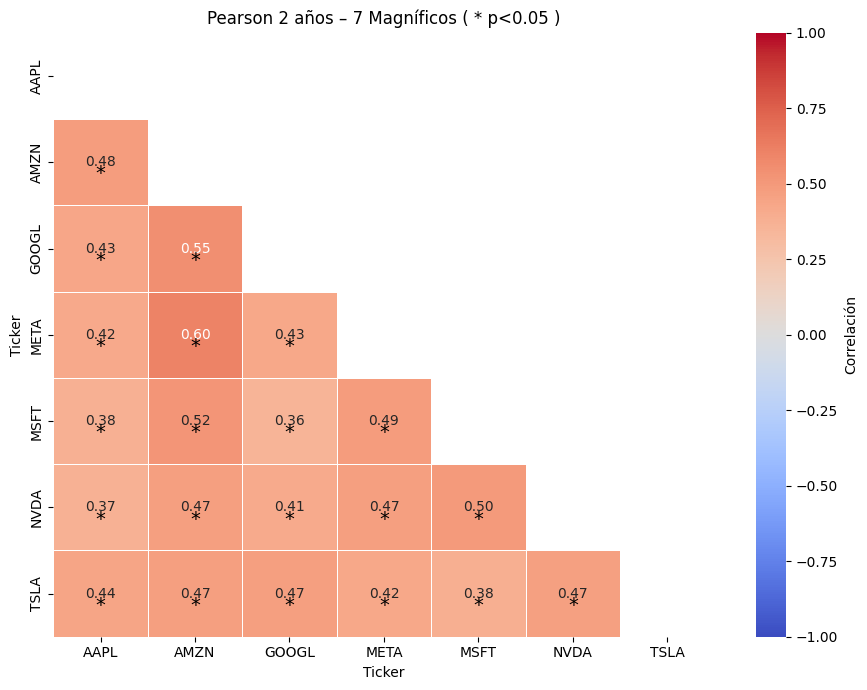

In [30]:
# p-values par a par (más robusto)
pvals = pd.DataFrame(np.ones(pearson_corr.shape), index=tickers, columns=tickers)
for i in tickers:
    for j in tickers:
        if i!=j:
            _, p = stats.pearsonr(returns[i], returns[j])
            pvals.loc[i,j] = p

mask = np.triu(np.ones_like(pearson_corr, dtype=bool))
plt.figure(figsize=(9,7))
sns.heatmap(pearson_corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1, linewidths=.5,
            cbar_kws={"label": "Correlación"})
# añade estrellas
for i in range(len(tickers)):
    for j in range(i):
        if pvals.iloc[i,j] < 0.05:
            plt.text(j+0.5, i+0.7, "*", ha='center', color='black', fontsize=14)
plt.title('Pearson 2 años – 7 Magníficos ( * p<0.05 )')
plt.tight_layout()

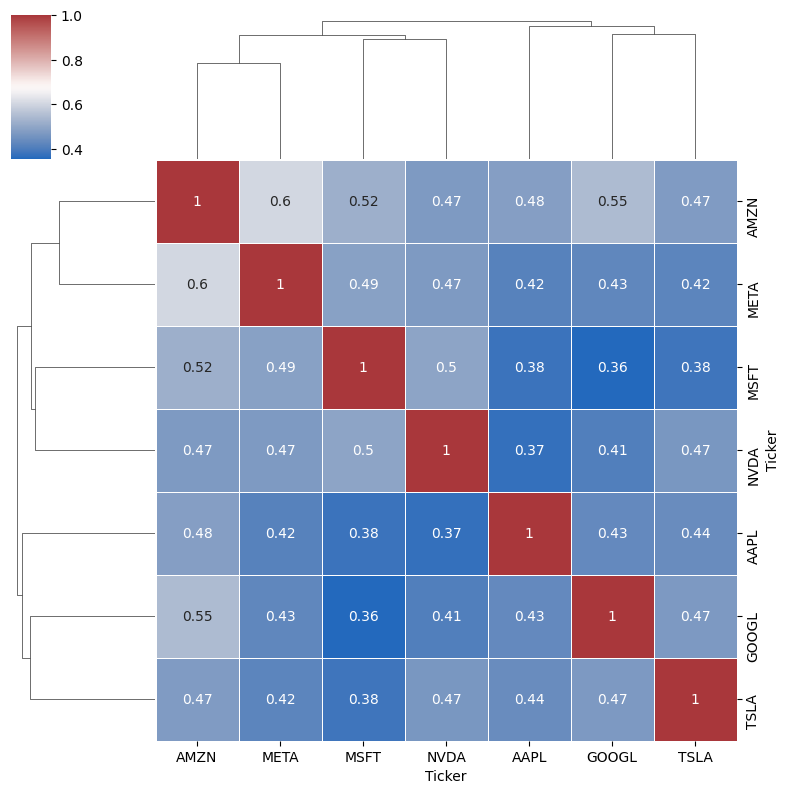

In [31]:
sns.clustermap(pearson_corr, cmap="vlag", annot=True,
               figsize=(8,8), linewidths=.5, method='average')

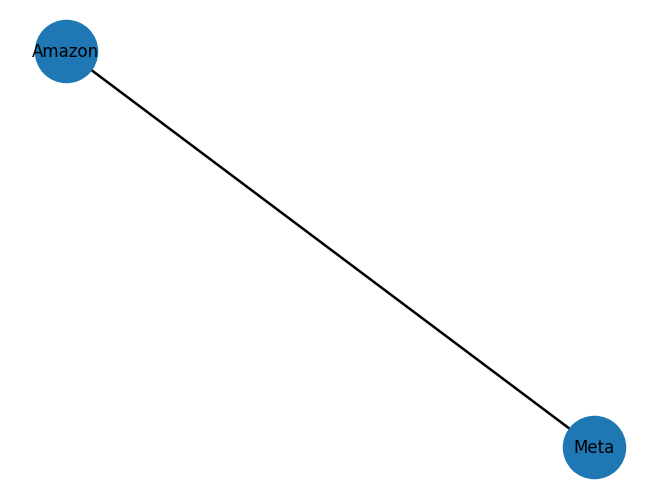

In [32]:
G = nx.Graph()
threshold = 0.6
for i in tickers:
    for j in tickers:
        if i<j and abs(pearson_corr.loc[i,j]) > threshold:
            G.add_edge(nombres[i], nombres[j], weight=pearson_corr.loc[i,j])

pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_size=2000,
        width=[d['weight']*3 for _,_,d in G.edges(data=True)])

Text(0, 0.5, 'Pearson')

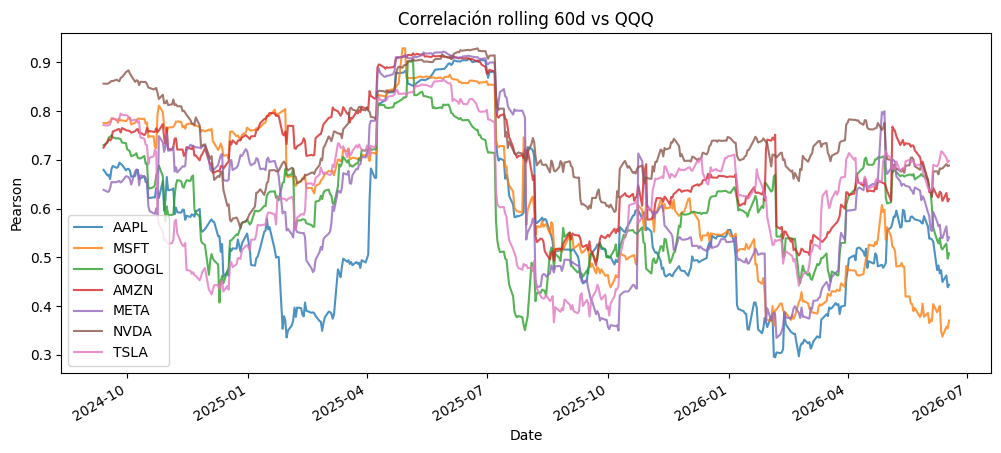

In [33]:
# Correlación rolling vs QQQ y SPY
window = 60 # ~3 meses
rolling = pd.DataFrame()
for t in tickers:
    rolling[t] = returns[t].rolling(window).corr(returns['QQQ'] if 'QQQ' in returns else benchmarks['QQQ'].pct_change())

rolling.plot(figsize=(12,5), alpha=0.8)
plt.title(f'Correlación rolling {window}d vs QQQ')
plt.ylabel('Pearson')

Top: Ticker  Ticker
AMZN    META      0.604939
        GOOGL     0.547115
dtype: float64
Bottom: Ticker  Ticker
TSLA    TSLA     NaN
dtype: float64


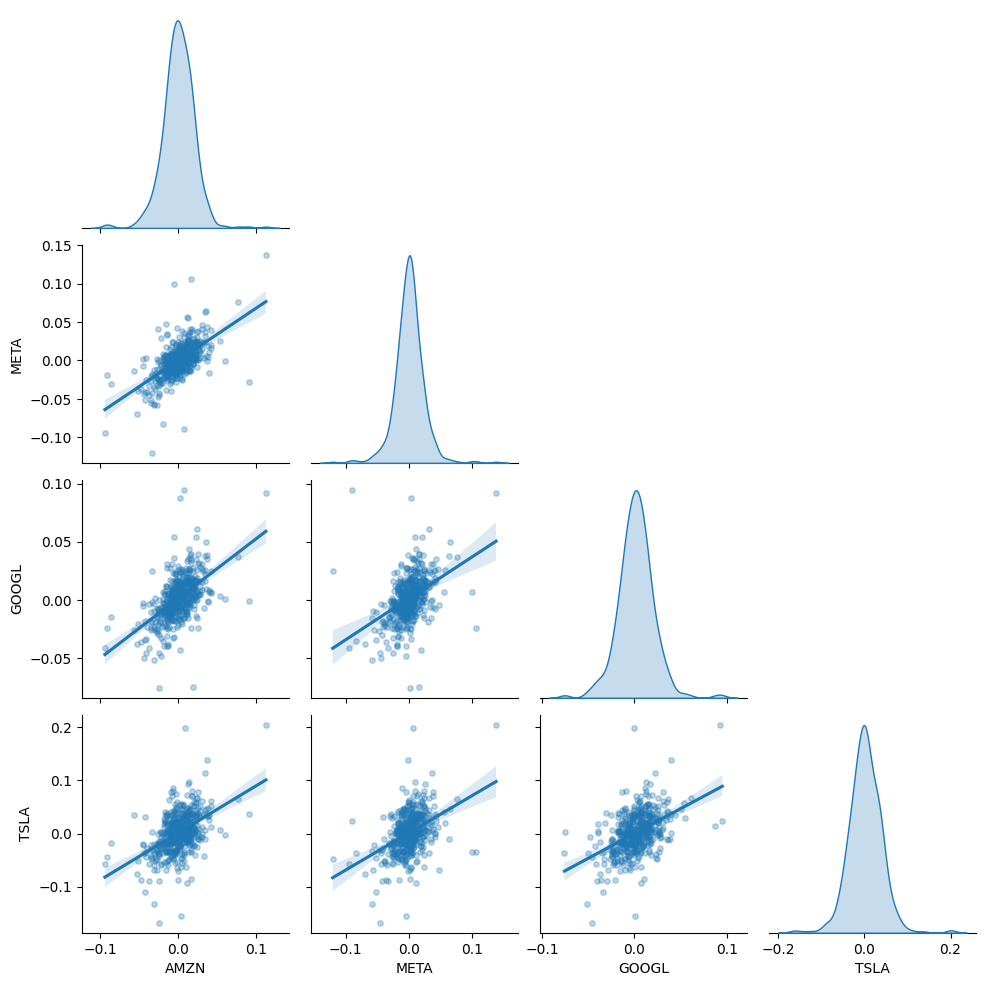

In [ ]:
# 1. trabaja con log_ret
mask = np.triu(np.ones(pearson_corr.shape), k=1).astype(bool)
pairs = pearson_corr.where(mask).stack().sort_values(ascending=False)

top_pairs = pairs.head(2)
bottom_pair = pairs.tail(1)

print("Top:", top_pairs)
print("Bottom:", bottom_pair)

# 3. lista única de tickers, sin repetir
tickers_plot = []
for a, b in list(top_pairs.index) + list(bottom_pair.index):
    tickers_plot.extend([a, b])

tickers_plot = list(dict.fromkeys(tickers_plot))  # mantiene orden y quita duplicados

# 4. pairplot limpio
sns.pairplot(
    returns_log[tickers_plot].dropna(),
    kind='reg',
    diag_kind='kde',
    plot_kws={'scatter_kws': {'alpha': 0.3, 's': 15}},
    corner=True  # opcional, evita la mitad duplicada del gráfico
)

In [ ]:
# El peor par es google con microsoft
pairs = pearson_corr.where(mask).stack().dropna().sort_values(ascending=False)
top_pairs = pairs.head(2)
bottom_pair = pairs.tail(1)
bottom_pair

Ticker  Ticker
GOOGL   MSFT      0.356064
dtype: float64

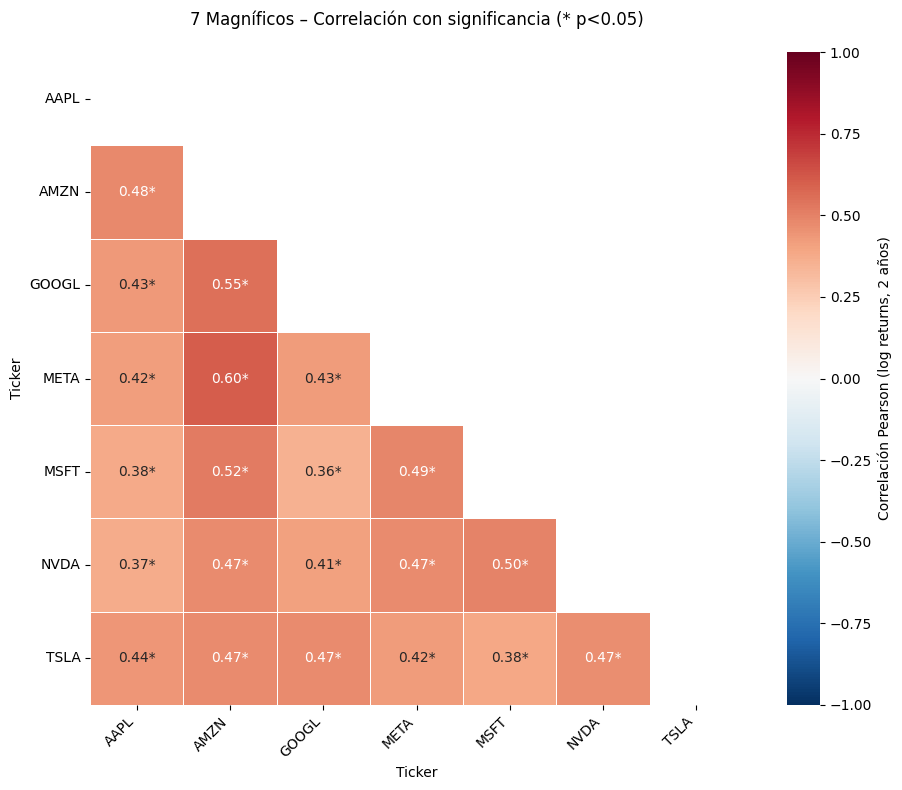

In [ ]:
# 1. máscara para mostrar solo triángulo inferior
mask = np.triu(np.ones_like(pearson_corr, dtype=bool))

# 2. anotaciones con * si p < 0.05
annot = pearson_corr.copy().round(2).astype(str)
for i in range(len(pearson_corr)):
    for j in range(len(pearson_corr)):
        if i > j:  # solo abajo
            r = pearson_corr.iloc[i, j]
            p = pearson_pvals.iloc[i, j]
            star = "*" if p < 0.05 else ""
            annot.iloc[i, j] = f"{r:.2f}{star}"
        else:
            annot.iloc[i, j] = ""

# 3. gráfico
plt.figure(figsize=(10,8))
sns.heatmap(
    pearson_corr,
    mask=mask,
    annot=annot,
    fmt="",
    cmap="RdBu_r",
    vmin=-1, vmax=1,
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Correlación Pearson (log returns, 2 años)"},
    square=True
)

plt.title("7 Magníficos – Correlación con significancia (* p<0.05)", pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [40]:
pairs

Ticker  Ticker
AMZN    META      0.604939
        GOOGL     0.547115
        MSFT      0.521902
MSFT    NVDA      0.495796
META    MSFT      0.488767
AAPL    AMZN      0.482666
AMZN    TSLA      0.474577
META    NVDA      0.473204
AMZN    NVDA      0.472647
GOOGL   TSLA      0.470376
NVDA    TSLA      0.465240
AAPL    TSLA      0.439858
        GOOGL     0.431910
GOOGL   META      0.428168
META    TSLA      0.422748
AAPL    META      0.416175
GOOGL   NVDA      0.407679
MSFT    TSLA      0.384890
AAPL    MSFT      0.380300
        NVDA      0.371717
GOOGL   MSFT      0.356064
dtype: float64

####################################################################
## **MÉTODO 2: SPEARMAN CORRELATION**
####################################################################

In [42]:
def spearman_analysis(returns):
    """Correlación de Spearman + p-values"""
    # correlación por rangos
    corr_matrix = returns.corr(method='spearman')

    # p-values par a par
    p_values = pd.DataFrame(
        np.zeros_like(corr_matrix),
        index=corr_matrix.index,
        columns=corr_matrix.columns
    )

    for i in corr_matrix.index:
        for j in corr_matrix.columns:
            if i!= j:
                _, p = spearmanr(returns[i], returns[j], nan_policy='omit')
                p_values.loc[i, j] = p
            else:
                p_values.loc[i, j] = 0.0

    return corr_matrix, p_values

spearman_corr, spearman_pvals = spearman_analysis(returns_log)

Text(0.5, 1.0, 'Spearman - Pearson (positivo = más relación monotónica que lineal)')

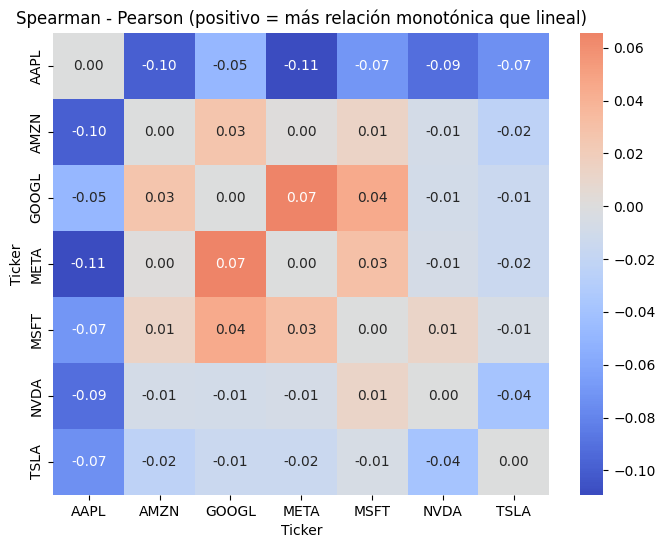

In [43]:
diff = spearman_corr - pearson_corr
plt.figure(figsize=(8,6))
sns.heatmap(diff, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Spearman - Pearson (positivo = más relación monotónica que lineal)")

In [44]:
mask = np.triu(np.ones(spearman_corr.shape), k=1).astype(bool)
top3_spearman = spearman_corr.where(mask).stack().sort_values(ascending=False).head(3)
print(top3_spearman)

Ticker  Ticker
AMZN    META      0.606008
        GOOGL     0.573711
        MSFT      0.534952
dtype: float64


In [45]:
top3_spearman

Ticker  Ticker
AMZN    META      0.606008
        GOOGL     0.573711
        MSFT      0.534952
dtype: float64

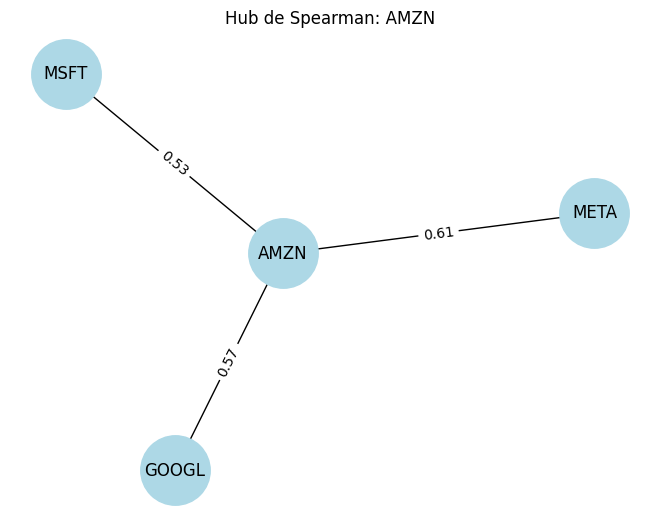

In [46]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
for (a,b), rho in top3_spearman.items():
    G.add_edge(a, b, weight=rho)

pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_size=2500, node_color='lightblue')
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels={k:f"{v:.2f}" for k,v in labels.items()})
plt.title("Hub de Spearman: AMZN")
plt.show()

In [47]:
# máscara del triángulo superior (sin duplicados ni diagonal)
mask = np.triu(np.ones(pearson_corr.shape), k=1).astype(bool)

# tabla comparativa
comparativa = pd.DataFrame({
    'Pearson': pearson_corr.where(mask).stack(),
    'Spearman': spearman_corr.where(mask).stack()
})
comparativa['Diferencia'] = comparativa['Spearman'] - comparativa['Pearson']
comparativa = comparativa.sort_values('Spearman', ascending=False)

# top 5 para ver el nuevo orden
print("Top 5 pares por Spearman (con log_returns):")
print(comparativa.head(5).round(3))

Top 5 pares por Spearman (con log_returns):
               Pearson  Spearman  Diferencia
Ticker Ticker                               
AMZN   META      0.605     0.606       0.001
       GOOGL     0.547     0.574       0.027
       MSFT      0.522     0.535       0.013
META   MSFT      0.489     0.519       0.031
MSFT   NVDA      0.496     0.508       0.012


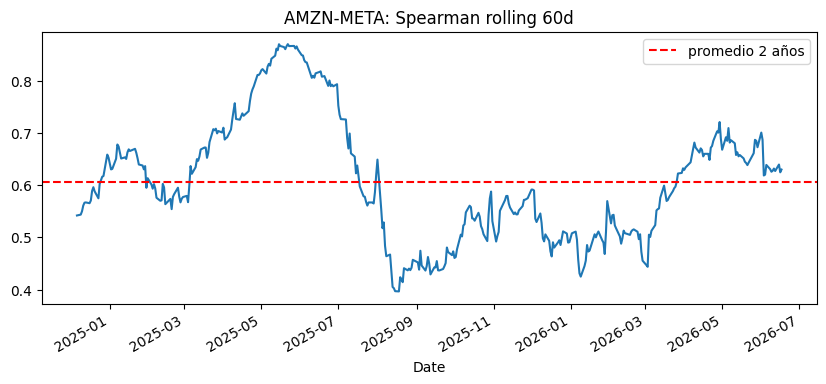

In [51]:
window = 60

# 1. Convertimos las series de retornos a sus rangos móviles dentro de la ventana de 60 días
rank_amzn = returns_log['AMZN'].rolling(window).rank()
rank_meta = returns_log['META'].rolling(window).rank()

# 2. Calculamos la correlación de Pearson sobre los rangos (que equivale a Spearman)
rolling_spearman = rank_amzn.rolling(window).corr(rank_meta)

# Tu código de graficación se mantiene igual
rolling_spearman.plot(figsize=(10,4), title='AMZN-META: Spearman rolling 60d')
plt.axhline(0.606, color='red', linestyle='--', label='promedio 2 años')
plt.legend()
plt.show()


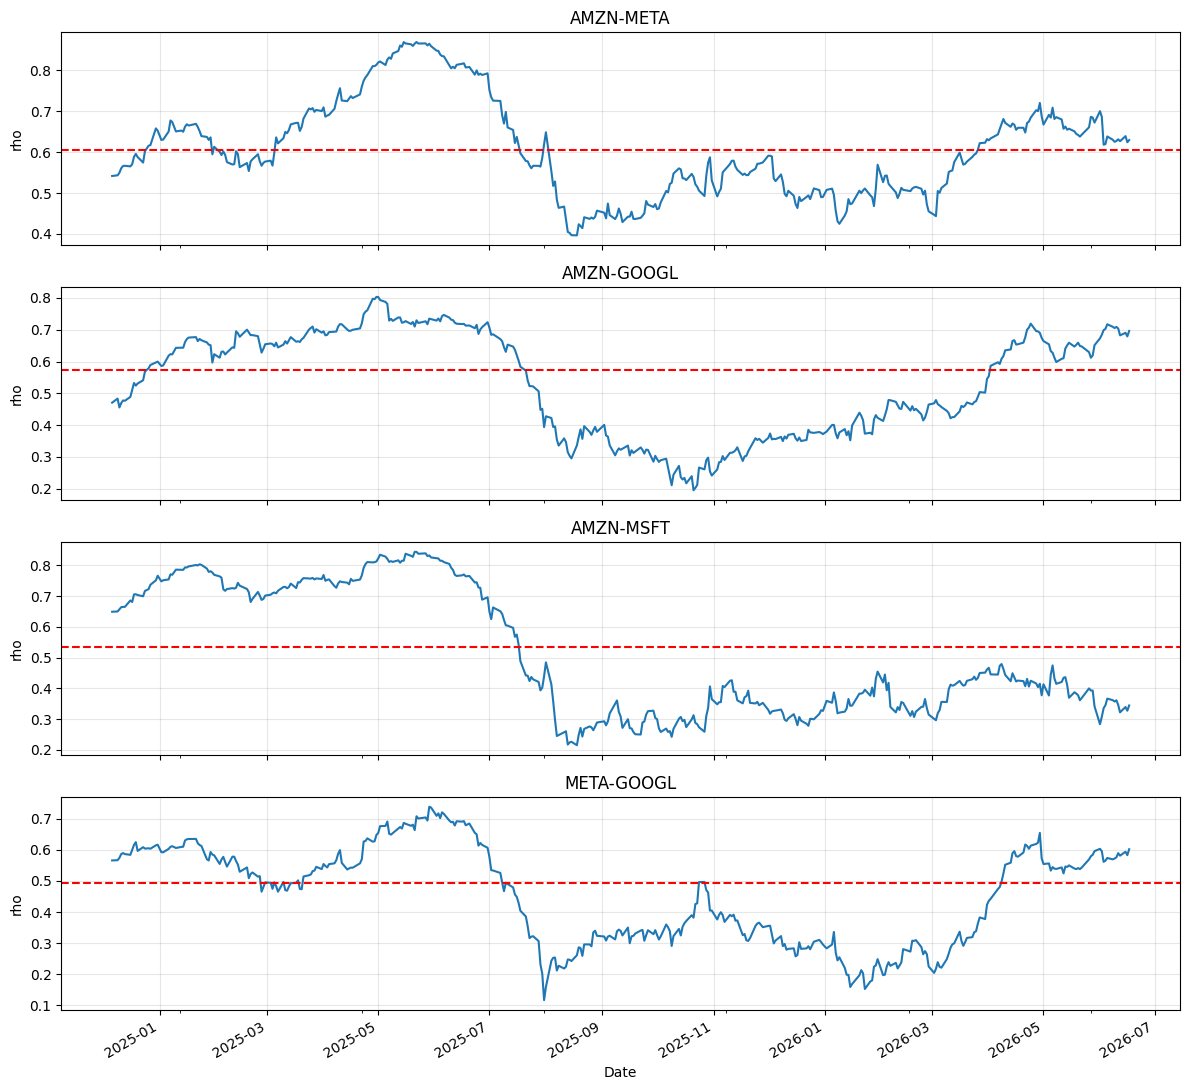

In [55]:
pares = [('AMZN','META'), ('AMZN','GOOGL'), ('AMZN','MSFT'), ('META','GOOGL')]
fig, axes = plt.subplots(4,1, figsize=(12,11), sharex=True)

for ax, (a,b) in zip(axes, pares):
    ra = returns_log[a].rolling(window).rank()
    rb = returns_log[b].rolling(window).rank()
    roll = ra.rolling(window).corr(rb)
    roll.plot(ax=ax)
    ax.axhline(spearman_corr.loc[a,b], color='red', linestyle='--')
    ax.set_title(f'{a}-{b}')
    ax.set_ylabel('rho')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

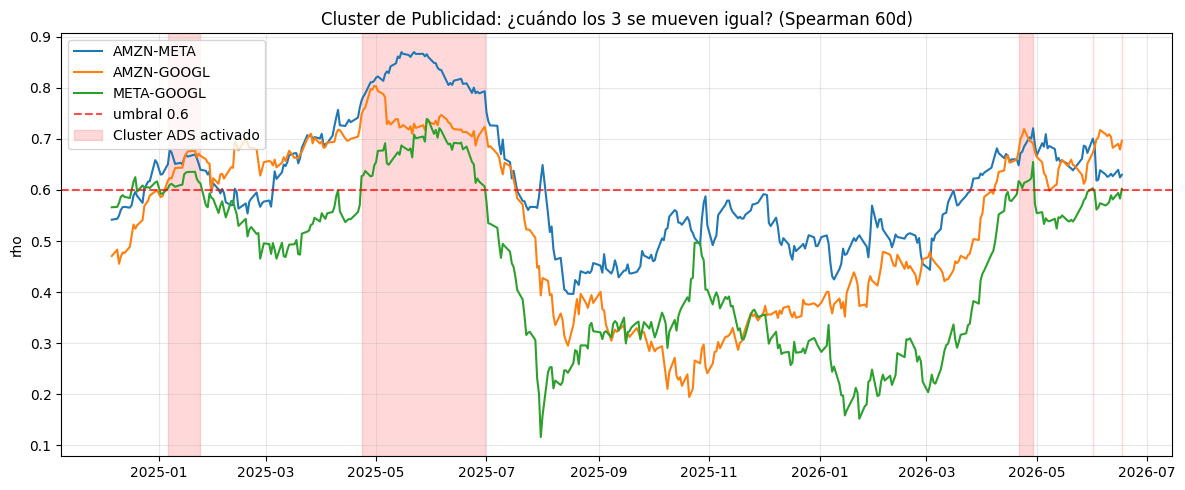

Periodos con cluster activo:
Última activación: 2026-06-17
Días totales en cluster en 2 años: 69 de 500


In [56]:
window = 60
umbral = 0.6

# 1. calcula los tres rolling Spearman con tu método
def rolling_spearman(a, b):
    ra = returns_log[a].rolling(window).rank()
    rb = returns_log[b].rolling(window).rank()
    return ra.rolling(window).corr(rb)

r_amzn_meta = rolling_spearman('AMZN','META')
r_amzn_googl = rolling_spearman('AMZN','GOOGL')
r_meta_googl = rolling_spearman('META','GOOGL')

# 2. señal de cluster
cluster_activo = (r_amzn_meta > umbral) & (r_amzn_googl > umbral) & (r_meta_googl > umbral)

# 3. gráfico
fig, ax = plt.subplots(figsize=(12,5))

ax.plot(r_amzn_meta, label='AMZN-META')
ax.plot(r_amzn_googl, label='AMZN-GOOGL')
ax.plot(r_meta_googl, label='META-GOOGL')
ax.axhline(umbral, color='red', linestyle='--', alpha=0.7, label='umbral 0.6')

# sombrea las zonas donde los tres están arriba
ax.fill_between(cluster_activo.index, 0, 1, where=cluster_activo,
                color='red', alpha=0.15, transform=ax.get_xaxis_transform(),
                label='Cluster ADS activado')

ax.set_title('Cluster de Publicidad: ¿cuándo los 3 se mueven igual? (Spearman 60d)')
ax.set_ylabel('rho')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4. opcional: fechas exactas
fechas_cluster = cluster_activo[cluster_activo].index
print("Periodos con cluster activo:")
for start, end in zip(fechas_cluster[::50], fechas_cluster[::50]): # ejemplo simple
    pass
print(f"Última activación: {fechas_cluster[-1].date() if len(fechas_cluster)>0 else 'ninguna'}")
print(f"Días totales en cluster en 2 años: {cluster_activo.sum()} de {len(cluster_activo)}")

In [57]:
if r_meta_googl.iloc[-1] > 0.6 and cluster_activo.iloc[-1]:
    print("ALERTA: Cluster ADS confirmado")
elif r_meta_googl.iloc[-1] > 0.58:
    print("Vigilancia: a 2 puntos de activar cluster")

ALERTA: Cluster ADS confirmado


In [58]:
window = 60
pares = [('AMZN','META'), ('AMZN','GOOGL'), ('AMZN','MSFT'), ('META','GOOGL')]

def rolling_spearman(a,b):
    ra = returns_log[a].rolling(window).rank()
    rb = returns_log[b].rolling(window).rank()
    return ra.rolling(window).corr(rb)

tabla = []
for a,b in pares:
    roll = rolling_spearman(a,b)
    promedio = spearman_corr.loc[a,b] # tu promedio de 2 años
    max_2025 = roll['2025'].max()
    hoy = roll.iloc[-1]
    tabla.append([f'{a}-{b}', round(promedio,3), round(max_2025,3), round(hoy,3)])

resumen = pd.DataFrame(tabla, columns=['Par','Promedio_2a','Max_2025','Hoy_17jun2026'])
print(resumen.to_string(index=False))

       Par  Promedio_2a  Max_2025  Hoy_17jun2026
 AMZN-META        0.606     0.870          0.630
AMZN-GOOGL        0.574     0.803          0.696
 AMZN-MSFT        0.535     0.844          0.344
META-GOOGL        0.494     0.739          0.602


* 2025 fue el año del todo-junto. Los cuatro pares tocaron 0.73 a 0.87 en junio. Ahí Pearson y Spearman te daban  casi lo mismo porque no había outliers, todo subía.
* Septiembre 2025 rompió el mercado. Por eso el promedio de 2 años (0.49 a 0.60) queda tan lejos de esos máximos.
* Hoy estás en un punto bisagra. AMZN-GOOGL en 0.696 y AMZN-META en 0.630 ya están en régimen alto

####################################################################
## **MÉTODO 3: DISTANCE CORRELATION**
####################################################################

In [61]:
pares = [('AMZN','META'), ('AMZN','GOOGL'), ('AMZN','MSFT'), ('META','GOOGL')]

resultados = []
for a,b in pares:
    x = returns_log[a].dropna().values
    y = returns_log[b].dropna().values
    # alinea por fecha
    df = returns_log[[a,b]].dropna()
    d = dcor.distance_correlation(df[a].values, df[b].values)

    # compara con lo que ya tienes
    pearson = df[a].corr(df[b])
    spearman = df[a].corr(df[b], method='spearman')

    resultados.append([f'{a}-{b}', round(pearson,3), round(spearman,3), round(d,3)])

tabla_dcor = pd.DataFrame(resultados, columns=['Par','Pearson','Spearman','dCor'])
print(tabla_dcor.to_string(index=False))

       Par  Pearson  Spearman  dCor
 AMZN-META    0.605     0.606 0.590
AMZN-GOOGL    0.547     0.574 0.551
 AMZN-MSFT    0.522     0.535 0.528
META-GOOGL    0.428     0.494 0.474


* AMZN-META 0.590 vs 0.606 – dCor es incluso un poco menor que Pearson y Spearman. Eso es señal de relación casi puramente lineal, sin estructura curva escondida. No hay "magia no lineal", es simplemente que se mueven juntos.
* AMZN-GOOGL 0.551 vs 0.574 – pasa lo mismo. La pequeña ganancia de Spearman sobre Pearson no se traduce en más dependencia compleja.
* AMZN-MSFT 0.528 vs 0.535 – idéntico. Cloud es lineal.
* META-GOOGL 0.474 vs 0.494 – aquí está lo interesante. Spearman subía de 0.428 a 0.494 y pensamos "hay monotonicidad", pero dCor se queda en 0.474, por debajo de Spearman. Eso te dice que esa ganancia no venía de una dependencia compleja, venía de algunos outliers que Spearman ordena mejor, pero que no aportan dependencia real extra.

In [63]:
def rolling_dcor(s1, s2, window=60):
    return s1.rolling(window).apply(lambda x: dcor.distance_correlation(
        x, s2.loc[x.index].values), raw=False)

r_dcor = rolling_dcor(returns_log['AMZN'], returns_log['META'])
r_dcor

Date
2024-06-20         NaN
2024-06-21         NaN
2024-06-24         NaN
2024-06-25         NaN
2024-06-26         NaN
                ...   
2026-06-11    0.624716
2026-06-12    0.621482
2026-06-15    0.637097
2026-06-16    0.627169
2026-06-17    0.644178
Name: AMZN, Length: 500, dtype: float64

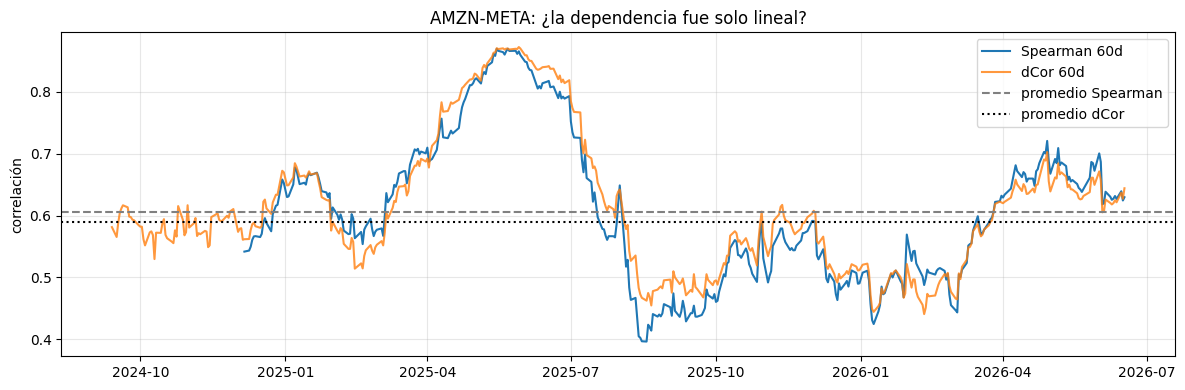

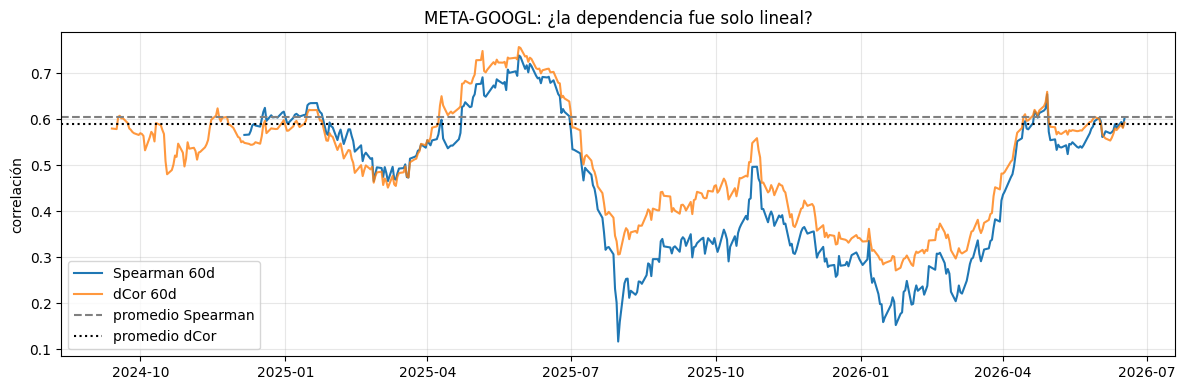

In [66]:
window = 60
a, b = 'AMZN', 'META'

# rolling dCor
def rolling_dcor(s1, s2):
    return s1.rolling(window).apply(
        lambda x: dcor.distance_correlation(x.values, s2.loc[x.index].values),
        raw=False
    )

dcor_roll = rolling_dcor(returns_log[a], returns_log[b])

# tu Spearman rolling ya lo tienes, si no:
ra = returns_log[a].rolling(window).rank()
rb = returns_log[b].rolling(window).rank()
spearman_roll = ra.rolling(window).corr(rb)

# plot comparativo
plt.figure(figsize=(12,4))
plt.plot(spearman_roll, label='Spearman 60d')
plt.plot(dcor_roll, label='dCor 60d', alpha=0.8)
plt.axhline(0.606, color='gray', linestyle='--', label='promedio Spearman')
plt.axhline(0.590, color='black', linestyle=':', label='promedio dCor')
plt.title('AMZN-META: ¿la dependencia fue solo lineal?')
plt.ylabel('correlación')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



window = 60
a, b = 'META','GOOGL'

# rolling dCor
def rolling_dcor(s1, s2):
    return s1.rolling(window).apply(
        lambda x: dcor.distance_correlation(x.values, s2.loc[x.index].values),
        raw=False
    )

dcor_roll = rolling_dcor(returns_log[a], returns_log[b])

# tu Spearman rolling ya lo tienes, si no:
ra = returns_log[a].rolling(window).rank()
rb = returns_log[b].rolling(window).rank()
spearman_roll = ra.rolling(window).corr(rb)

# plot comparativo
plt.figure(figsize=(12,4))
plt.plot(spearman_roll, label='Spearman 60d')
plt.plot(dcor_roll, label='dCor 60d', alpha=0.8)
plt.axhline(0.606, color='gray', linestyle='--', label='promedio Spearman')
plt.axhline(0.590, color='black', linestyle=':', label='promedio dCor')
plt.title('META-GOOGL: ¿la dependencia fue solo lineal?')
plt.ylabel('correlación')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

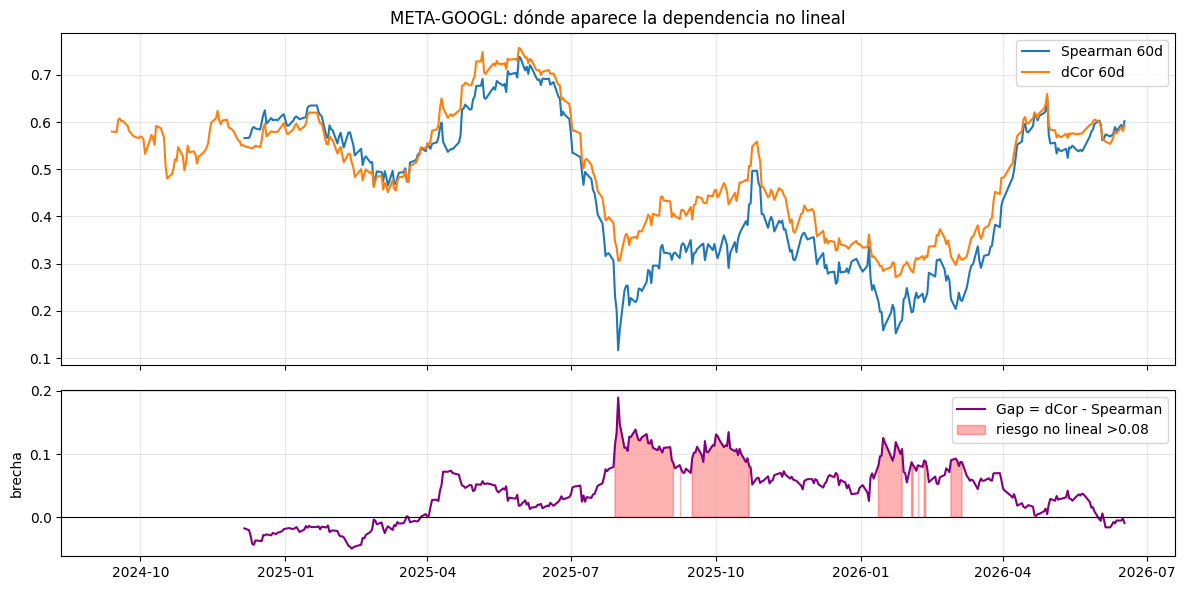

Promedio brecha: 0.043
Máxima brecha: 0.189 el 2025-07-31
Días con brecha >0.08: 77 de 500
Primer periodo fuerte: 2025-07-29 a 2026-03-06


In [67]:
a, b = 'META', 'GOOGL'
window = 60

# ya los tienes, si no recalcula rápido
ra = returns_log[a].rolling(window).rank()
rb = returns_log[b].rolling(window).rank()
spearman_roll = ra.rolling(window).corr(rb)

dcor_roll = returns_log[a].rolling(window).apply(
    lambda x: dcor.distance_correlation(x.values, returns_log[b].loc[x.index].values),
    raw=False
)

# 1. la brecha
gap = dcor_roll - spearman_roll

# 2. plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,6), sharex=True, gridspec_kw={'height_ratios':[2,1]})

# arriba las dos curvas que ya conoces
ax1.plot(spearman_roll, label='Spearman 60d')
ax1.plot(dcor_roll, label='dCor 60d')
ax1.set_title('META-GOOGL: dónde aparece la dependencia no lineal')
ax1.legend()
ax1.grid(alpha=0.3)

# abajo la brecha
ax2.plot(gap, color='purple', label='Gap = dCor - Spearman')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.fill_between(gap.index, 0, gap, where=gap>0.08, color='red', alpha=0.3, label='riesgo no lineal >0.08')
ax2.set_ylabel('brecha')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 3. fechas clave
alto_riesgo = gap[gap > 0.08]
print(f"Promedio brecha: {gap.mean():.3f}")
print(f"Máxima brecha: {gap.max():.3f} el {gap.idxmax().date()}")
print(f"Días con brecha >0.08: {len(alto_riesgo)} de {len(gap)}")
print("Primer periodo fuerte:", alto_riesgo.index.min().date(), "a", alto_riesgo.index.max().date())

* **Script pearson, sperman y distacia de correlación**

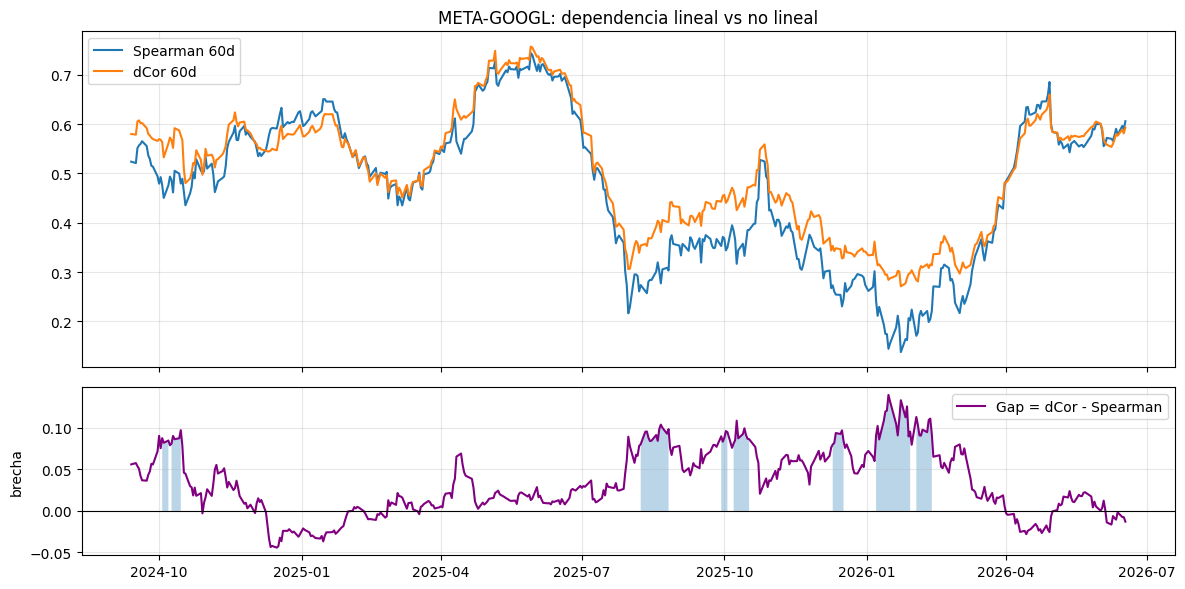

       Par  Pearson  Spearman  dCor  Gap_prom  Gap_max Fecha_max_gap  Dias_gap_alto
META-GOOGL    0.428     0.494 0.474     0.034     0.14    2026-01-15             70


In [73]:
def analiza_par(t1, t2, returns_log, window=60, umbral_gap=0.08):
    df = returns_log[[t1, t2]].dropna()

    # 1. métricas globales
    pearson = df.corr().iloc[0, 1]
    spearman = df.corr(method='spearman').iloc[0, 1]
    dcor_val = dcor.distance_correlation(df[t1].values, df[t2].values)

    # 2. rolling
    spearman_roll = []
    dcor_roll = []
    idxs = []

    for i in range(window - 1, len(df)):
        w = df.iloc[i-window+1:i+1]

        sp = w.corr(method='spearman').iloc[0, 1]
        dc = dcor.distance_correlation(w[t1].values, w[t2].values)

        spearman_roll.append(sp)
        dcor_roll.append(dc)
        idxs.append(w.index[-1])

    spearman_roll = pd.Series(spearman_roll, index=idxs)
    dcor_roll = pd.Series(dcor_roll, index=idxs)

    gap = dcor_roll - spearman_roll

    # 3. tabla resumen
    resumen = pd.DataFrame([{
        'Par': f'{t1}-{t2}',
        'Pearson': round(pearson, 3),
        'Spearman': round(spearman, 3),
        'dCor': round(dcor_val, 3),
        'Gap_prom': round(gap.mean(), 3),
        'Gap_max': round(gap.max(), 3),
        'Fecha_max_gap': gap.idxmax().date(),
        'Dias_gap_alto': int((gap > umbral_gap).sum())
    }])

    # 4. plot
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(12, 6), sharex=True,
        gridspec_kw={'height_ratios': [2, 1]}
    )

    ax1.plot(spearman_roll.index, spearman_roll, label='Spearman 60d')
    ax1.plot(dcor_roll.index, dcor_roll, label='dCor 60d')
    ax1.set_title(f'{t1}-{t2}: dependencia lineal vs no lineal')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(gap.index, gap, color='purple', label='Gap = dCor - Spearman')
    ax2.axhline(0, color='black', lw=0.8)
    ax2.fill_between(gap.index, 0, gap, where=gap > umbral_gap, alpha=0.3)
    ax2.set_ylabel('brecha')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    return resumen, spearman_roll, dcor_roll, gap


# EJEMPLO DE USO
resumen_mg, _, _, _ = analiza_par('META', 'GOOGL', returns_log)
print(resumen_mg.to_string(index=False))

# para los otros pares
# analiza_par('AMZN','META', returns_log)
# analiza_par('AMZN','GOOGL', returns_log)
# analiza_par('AMZN','MSFT', returns_log)